# 一、导包及数据获取
    数据来源：和鲸社区
    数据量：2w
    客户细分和分析（用户画像）
    探索性数据分析（EDA）
    

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.weightstats as ws
from scipy import stats
pd.options.mode.chained_assignment = None
%matplotlib inline
plt.rcParams['font.sans-serif']='SimHei'
plt.rcParams['axes.unicode_minus']=False
%config InlineBackend.figure_format ='svg'
sales_data=pd.read_excel(r"C:\Users\wang\Downloads\优衣库.xls",'优衣库')

# 二、数据清洗

查看数据概况

In [3]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19085 entries, 0 to 19084
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   商店ID     18951 non-null  float64       
 1   门店所在城市   18951 non-null  object        
 2   渠道       18951 non-null  object        
 3   性别群体     18951 non-null  object        
 4   年龄群体     18951 non-null  object        
 5   产品类别     18951 non-null  object        
 6   客户数量     18951 non-null  float64       
 7   销售金额     18951 non-null  float64       
 8   订单数量     18951 non-null  float64       
 9   购买的产品数量  18951 non-null  float64       
 10  成本       18951 non-null  float64       
 11  单价       18951 non-null  float64       
 12  利润       18951 non-null  float64       
 13  订单日期     18951 non-null  datetime64[ns]
 14  星期       18951 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(6)
memory usage: 2.2+ MB


查看含有空值的所有行

In [4]:
empty=sales_data[sales_data.isnull().any(axis=1)]
empty


,商店ID,门店所在城市,渠道,性别群体,年龄群体,产品类别,客户数量,销售金额,订单数量,购买的产品数量,成本,单价,利润,订单日期,星期
527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
18783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
18885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
18919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN


清理含空值的行以及重复行

In [5]:
sales_data=sales_data.dropna()
sales_data=sales_data.drop_duplicates()
sales_data=sales_data.reset_index(drop=True)

查看统计概要

In [6]:
sales_data.describe()

,商店ID,客户数量,销售金额,订单数量,购买的产品数量,成本,单价,利润,订单日期
count,18918.000000,18918.000000,18918.000000,18918.000000,18918.000000,18918.000000,18918.000000,18918.000000,18918
mean,333.941960,1.728565,171.746851,1.754942,1.995507,45.921979,84.438418,81.182362,2023-07-15 07:29:56.003805952
min,19.000000,1.000000,-0.660000,1.000000,1.000000,9.000000,0.000000,-650.000000,2023-01-01 00:00:00
25%,142.000000,1.000000,59.000000,1.000000,1.000000,29.000000,49.000000,16.000000,2023-04-28 00:00:00
50%,315.000000,1.000000,99.000000,1.000000,1.000000,49.000000,79.000000,42.000000,2023-07-16 00:00:00
75%,480.000000,2.000000,198.000000,2.000000,2.000000,59.000000,99.000000,100.000000,2023-10-13 00:00:00
max,831.000000,58.000000,12538.000000,65.000000,84.000000,99.000000,299.000000,8408.000000,2023-12-31 00:00:00
std,229.731367,1.917046,297.721875,1.998915,2.519141,20.233436,49.250892,194.166122,NaN


In [7]:
sales_data.to_csv('cleaned_data_uniqlo.csv')

查看数据概况

In [8]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18918 entries, 0 to 18917
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   商店ID     18918 non-null  float64       
 1   门店所在城市   18918 non-null  object        
 2   渠道       18918 non-null  object        
 3   性别群体     18918 non-null  object        
 4   年龄群体     18918 non-null  object        
 5   产品类别     18918 non-null  object        
 6   客户数量     18918 non-null  float64       
 7   销售金额     18918 non-null  float64       
 8   订单数量     18918 non-null  float64       
 9   购买的产品数量  18918 non-null  float64       
 10  成本       18918 non-null  float64       
 11  单价       18918 non-null  float64       
 12  利润       18918 non-null  float64       
 13  订单日期     18918 non-null  datetime64[ns]
 14  星期       18918 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(6)
memory usage: 2.2+ MB


# 三、 探索性数据分析 (EDA)
    对清洗后数据的深度挖掘，包括增加新的特征维度（如价格区间、工作日/周末分类）以便进行细分分析。

In [9]:
sales_data['价格区间']=pd.cut(sales_data['单价'],bins=[0, 59, 99, 159, 199, 299, 399, 5000],labels=['0-59', '59-99', '99-159', '159-199', '199-299', '299-399', '399以上'],include_lowest=True)
sales_data['时间类别']=np.where(sales_data['星期'].isin(['星期六','星期日']),'周末','工作日')
sales_data['单笔利润']=sales_data['利润']/sales_data['订单数量']

## 3.1 渠道与客群多维分析
探究不同性别群体在渠道选择（线上 vs 线下）上的差异，以及各城市门店的盈利表现

### 3.1.1不同性别客群的渠道偏好
分析目标： 观察男女客群在购买渠道上是否存在显著差异，为精准营销提供依据

### 3.1.2城市维度下的单笔利润和数量分析
分析目标： 衡量不同城市门店的运营效率，通过“总订单数量”指标观察渠道偏好，通过“单笔利润”指标排除单纯因人流量导致的利润偏差


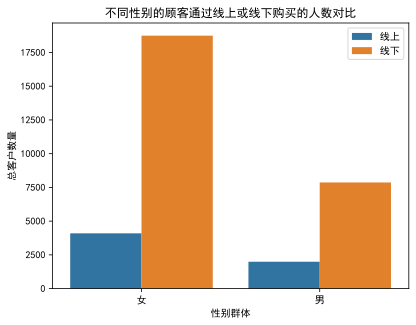

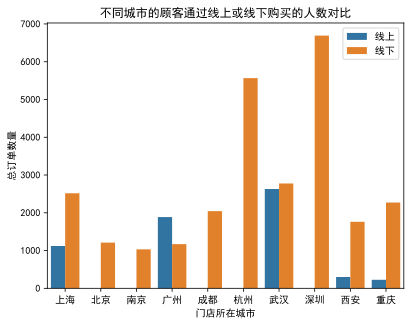

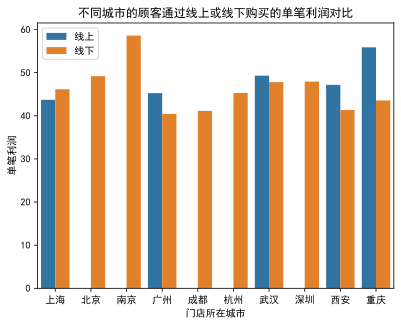

In [10]:
gender_pivot=pd.DataFrame(sales_data.groupby(['性别群体','渠道'])['客户数量'].sum())
gender_pivot=gender_pivot.rename(columns={'客户数量':'总客户数量'}).reset_index()
sns.barplot(data=gender_pivot, x='性别群体', y='总客户数量', hue='渠道')
plt.legend()
plt.title('不同性别的顾客通过线上或线下购买的人数对比')
plt.show()
city_pivot=pd.DataFrame(sales_data.groupby(['门店所在城市','渠道']).agg({'客户数量':'sum','订单数量':'sum','利润':'sum'})).rename(
    columns={'客户数量':'总客户数量','订单数量':'总订单数量','利润':'总利润'}).reset_index()
city_pivot['单笔利润']=city_pivot['总利润']/city_pivot['总订单数量']
sns.barplot(data=city_pivot, x='门店所在城市', y='总订单数量', hue='渠道')
plt.legend()
plt.title('不同城市的顾客通过线上或线下购买的人数对比')
plt.show()
sns.barplot(data=city_pivot, x='门店所在城市', y='单笔利润', hue='渠道')
plt.legend()
plt.title('不同城市的顾客通过线上或线下购买的单笔利润对比')
plt.show()




## 3.2 销售情况多维度分析
这一部分通过对产品类别与销售渠道进行交叉分析，探究不同品类的市场表现及渠道偏好。

### 3.2.1聚合计算各品类、渠道的销售指标
统计了每个品类在不同渠道下的总订单量、总利润、总销售额，并计算了单笔利润和平均单价，以评估其盈利能力。

## 3.3用户画像分析：高价值客户挖掘
通过对性别、年龄段、销售渠道进行多维交叉分析，通过计算“单笔利润”来识别高价值客户

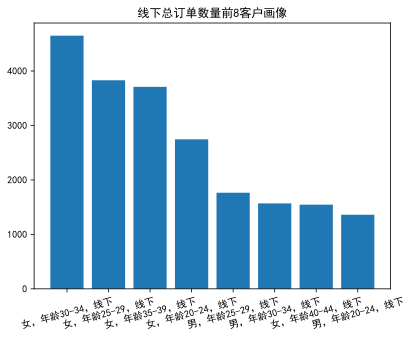

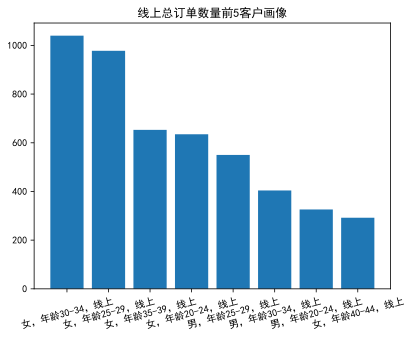

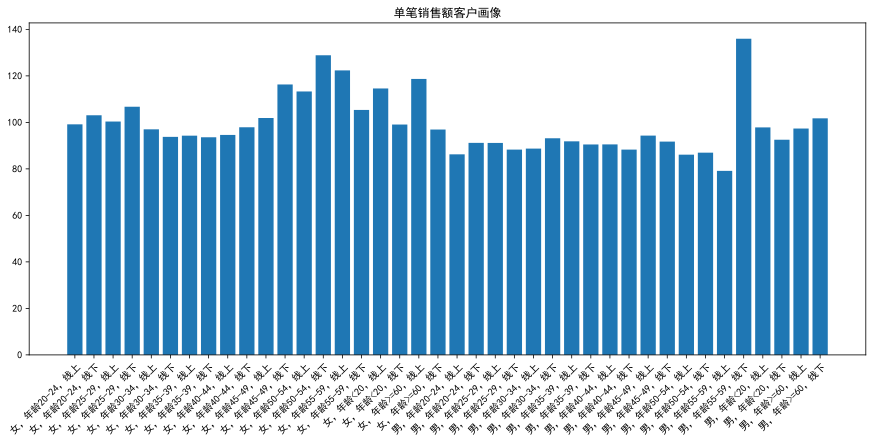

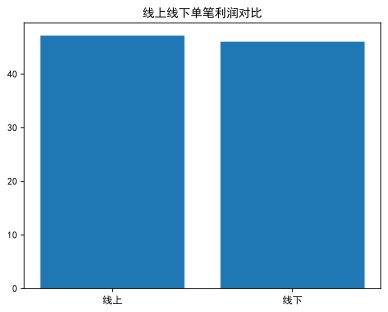

,性别群体,年龄群体,渠道,总销售金额,总利润,总订单数量,总客户数量,单笔利润,单笔销售额,客户画像
0,女,20-24,线上,62968.63,31789.63,635.0,626.0,50.062409,99.163197,女，年龄20-24，线上
1,女,20-24,线下,282999.15,143188.15,2746.0,2705.0,52.144264,103.058685,女，年龄20-24，线下
2,女,25-29,线上,98151.60,51277.60,978.0,973.0,52.431084,100.359509,女，年龄25-29，线上
3,女,25-29,线下,408812.61,209469.61,3830.0,3755.0,54.691804,106.739585,女，年龄25-29，线下
4,女,30-34,线上,100890.27,48223.27,1040.0,1017.0,46.368529,97.009875,女，年龄30-34，线上
5,女,30-34,线下,435954.91,195430.91,4649.0,4589.0,42.037193,93.773911,女，年龄30-34，线下
6,女,35-39,线上,61560.52,27036.52,653.0,644.0,41.403553,94.273384,女，年龄35-39，线上
7,女,35-39,线下,347120.85,150275.85,3709.0,3653.0,40.516541,93.588798,女，年龄35-39，线下
8,女,40-44,线上,27626.53,12985.53,292.0,287.0,44.470993,94.611404,女，年龄40-44，线上
9,女,40-44,线下,151327.06,69009.06,1546.0,1496.0,44.637167,97.882962,女，年龄40-44，线下


In [17]:
person_rank=pd.DataFrame(sales_data.groupby(['性别群体','年龄群体','渠道']).agg({'销售金额':'sum','利润':'sum','订单数量':'sum','客户数量':'sum'})).rename(
    columns={'销售金额':'总销售金额','客户数量':'总客户数量','订单数量':'总订单数量','利润':'总利润'}).reset_index()
person_rank['单笔利润']=person_rank['总利润']/person_rank['总订单数量']
person_rank['单笔销售额']=person_rank['总销售金额']/person_rank['总订单数量']
person_rank['客户画像']=person_rank['性别群体']+'，年龄'+person_rank['年龄群体']+'，'+person_rank['渠道']
top_8_online = person_rank[person_rank['渠道']=='线上'].sort_values(by='总订单数量', ascending=False).head(8)
top_8_offline=person_rank[person_rank['渠道']=='线下'].sort_values(by='总订单数量', ascending=False).head(8)
plt.bar(x=top_8_offline['客户画像'],height=top_8_offline['总订单数量'])
plt.xticks(rotation=15)
plt.title('线下总订单数量前8客户画像')
plt.show()
plt.bar(x=top_8_online['客户画像'],height=top_8_online['总订单数量'])
plt.xticks(rotation=15)
plt.title('线上总订单数量前5客户画像')
plt.show()
plt.figure(figsize=(15, 6))
plt.bar(x=person_rank['客户画像'],height=person_rank['单笔销售额'])
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title('单笔销售额客户画像')
plt.show()
summary=pd.DataFrame(person_rank.groupby(['渠道']).agg({'总利润':'sum','总订单数量':'sum'})).reset_index()
summary['单笔利润']=summary['总利润']/summary['总订单数量']
plt.bar(summary['渠道'],height=summary['单笔利润'])
plt.title('线上线下单笔利润对比')
plt.show()
person_rank


## 3.4 时间维度与渠道交叉分析
研究**时间类别（周末 vs 工作日）**对销售表现的影响。通过分析不同时段的订单量和运营效率，可以为门店排班和线上促销时机提供决策依据时间维度与渠道交叉分析


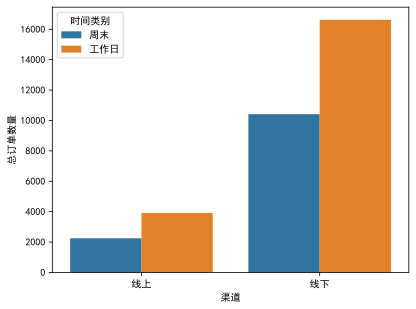

,时间类别,渠道,总订单数量,总利润,总客户数量,单笔利润,UPT
0,周末,线上,2249.0,107796.94,2218.0,47.931054,1.013977
1,周末,线下,10414.0,484336.81,10268.0,46.508240,1.014219
2,工作日,线上,3914.0,183000.54,3869.0,46.755376,1.011631
3,工作日,线下,16623.0,760673.64,16346.0,45.760310,1.016946


In [11]:
time_pivot=pd.DataFrame(sales_data.groupby(['时间类别','渠道']).agg(总订单数量=('订单数量','sum'),总利润=('利润','sum'),总客户数量=('客户数量','sum'))).reset_index()
time_pivot['单笔利润']=time_pivot['总利润']/time_pivot['总订单数量']
time_pivot['UPT']=time_pivot['总订单数量']/time_pivot['总客户数量']
time_pivot
sns.barplot(data=time_pivot,x='渠道',y='总订单数量',hue='时间类别')
plt.show()
time_pivot



## 3.5产品维度：渠道差异与热销排名分析
重点关注不同产品类别在不同渠道的表现，通过对比“线上”与“线下”的销量排名，识别渠道专属的热销产品

In [12]:
product_pivot=pd.DataFrame(sales_data.groupby(['产品类别','渠道']).agg(总订单数量=('订单数量','sum'),总利润=('利润','sum'),总销售额=('销售金额','sum'))).reset_index()
product_pivot['平均单笔利润']=product_pivot['总利润']/product_pivot['总订单数量']
product_pivot['平均单价']=product_pivot['总销售额']/product_pivot['总订单数量']
product_online_pivot=product_pivot[product_pivot['渠道']=='线上'].sort_values(by='总订单数量',ascending=False)
product_offline_pivot=product_pivot[product_pivot['渠道']=='线下'].sort_values(by='总订单数量',ascending=False)
sales_difference=pd.concat([product_offline_pivot['产品类别'].reset_index(drop=True),product_online_pivot['产品类别'].reset_index(drop=True)],axis=1)
sales_difference.columns=['线下产品销售量排名','线上产品销售量排名']
sales_difference

,线下产品销售量排名,线上产品销售量排名
0,T恤,T恤
1,当季新品,配件
2,配件,当季新品
3,袜子,袜子
4,牛仔裤,短裤
5,短裤,牛仔裤
6,运动,运动
7,毛衣,毛衣
8,裙子,裙子


In [13]:
product_offline_pivot.reset_index(drop=True)

,产品类别,渠道,总订单数量,总利润,总销售额,平均单笔利润,平均单价
0,T恤,线下,11231.0,418669.47,1036069.47,37.278022,92.250865
1,当季新品,线下,3960.0,240667.47,499382.47,60.774614,126.106684
2,配件,线下,3046.0,234900.15,337212.15,77.117580,110.706550
3,袜子,线下,2111.0,71287.34,96514.34,33.769465,45.719725
4,牛仔裤,线下,1843.0,62920.52,198022.52,34.140271,107.445751
5,短裤,线下,1770.0,40471.57,80333.57,22.865294,45.386198
6,运动,线下,1260.0,25407.98,97829.98,20.165063,77.642841
7,毛衣,线下,1005.0,87855.17,195864.17,87.418080,194.889721
8,裙子,线下,811.0,62830.78,111564.78,77.473218,137.564464


In [14]:
product_online_pivot.reset_index(drop=True)

,产品类别,渠道,总订单数量,总利润,总销售额,平均单笔利润,平均单价
0,T恤,线上,2477.0,101340.25,233983.25,40.912495,94.462354
1,配件,线上,877.0,70827.00,100813.00,80.760547,114.952109
2,当季新品,线上,776.0,32904.25,83290.25,42.402384,107.332796
3,袜子,线上,538.0,18562.38,24907.38,34.502565,46.296245
4,短裤,线上,486.0,11128.31,22528.31,22.897757,46.354547
5,牛仔裤,线上,364.0,15278.96,42119.96,41.975165,115.714176
6,运动,线上,255.0,4387.70,18744.70,17.206667,73.508627
7,毛衣,线上,234.0,22031.63,46385.63,94.152265,198.229188
8,裙子,线上,156.0,14337.00,23541.00,91.903846,150.903846


# 四、统计检验分析

##  4.1 全量视角下单笔利润线上线下显著性检验

In [15]:
# 线上组
online_profit = sales_data[sales_data['渠道'] == '线上']['单笔利润']
# 线下组
offline_profit = sales_data[sales_data['渠道'] == '线下']['单笔利润']

# 2. 执行 T-检验 (以单笔利润为例)
# usevar='pooled' 假设方差齐性；'unequal' 对应 Welch's T-test（更稳健）
t_stat, p_value, df_deg = ws.ttest_ind(online_profit, offline_profit, usevar='unequal')

print(f"--- 单笔利润 T-检验结果 ---")
print(f"T统计量 (T-statistic): {t_stat:.4f}")
print(f"P值 (P-value): {p_value:.4f}")

# 3. 结果判断
alpha = 0.05
if p_value < alpha:
    print("结论：全量数据视角，在 5% 的显著性水平下，线上线下单笔利润有显著差异。")
else:
    print("结论：全量数据视角，在 5% 的显著性水平下，线上线下单笔利润无显著差异。")
# 计算均值
mean_on = online_profit.mean()
mean_off = offline_profit.mean()

# 计算差额和增长率
diff = mean_on - mean_off
percentage = (diff / mean_off) * 100

print(f"线上平均单笔利润: {mean_on:.2f} 元")
print(f"线下平均单笔利润: {mean_off:.2f} 元")
print(f"绝对差值: {diff:.2f} 元")
print(f"线上比线下利润高出: {percentage:.2f}%")

# 结合 P 值给出最终结论
if p_value < 0.05:
    winner = "线上" if mean_on > mean_off else "线下"
    print(f"结论：{winner}渠道的盈利能力显著更强。")

--- 单笔利润 T-检验结果 ---
T统计量 (T-statistic): 2.6062
P值 (P-value): 0.0092
结论：全量数据视角，在 5% 的显著性水平下，线上线下单笔利润有显著差异。
线上平均单笔利润: 44.09 元
线下平均单笔利润: 41.67 元
绝对差值: 2.42 元
线上比线下利润高出: 5.82%
结论：线上渠道的盈利能力显著更强。


##  4.2 画像策略单笔利润线上线下显著性检验

In [16]:
# 线上组
online_profit = person_rank[person_rank['渠道'] == '线上']['单笔利润']
# 线下组
offline_profit = person_rank[person_rank['渠道'] == '线下']['单笔利润']

# 2. 执行 T-检验 (以单笔利润为例)
t_stat, p_value, df_deg = ws.ttest_ind(online_profit, offline_profit, usevar='unequal')

print(f"--- 单笔利润 T-检验结果 ---")
print(f"T统计量 (T-statistic): {t_stat:.4f}")
print(f"P值 (P-value): {p_value:.4f}")

# 3. 结果判断
alpha = 0.05
if p_value < alpha:
    print("结论：画像策略视角下，在 5% 的显著性水平下，线上线下单笔利润有显著差异。")
else:
    print("结论：画像策略视角下，在 5% 的显著性水平下，线上线下单笔利润无显著差异。")

--- 单笔利润 T-检验结果 ---
T统计量 (T-statistic): 0.7000
P值 (P-value): 0.4883
结论：画像策略视角下，在 5% 的显著性水平下，线上线下单笔利润无显著差异。


# 五、业务洞察

## 5.1、核心业务洞察
    从性别、城市及时间等多维度分析，线下渠道订单量均显著高于线上渠道，表现出稳定的规模优势。进一步结合统计检验结果：在全量数据下，线下与线上渠道利润存在显著差异，但在控制用户结构后，该差异不再显著。渠道并非利润差异的核心驱动因素，用户结构（高价值用户占比）才是关键影响变量
## 5.2、销售由核心女性客群驱动
     数据表明，消费人群以女性为主，且主要集中在20–39岁区间，在线上线下渠道中均表现一致。核心用户群体高度集中，目标客群画像清晰，具备规模化运营基础。
## 5.3、消费行为以“目的性购买”为主导
     无论线上还是线下，工作日订单量均显著高于周末，且线下渠道在各时间段均占主导。说明客户群体的消费行为更多嵌入日常生活场景，购买行为具有一定“刚需属性”。
## 5.4、产品结构呈现“基础款驱动”特征
     线上与线下渠道的热销产品类别高度一致，均以基础款为主，而裙装等偏时尚类商品销量较低。说明：用户需求以“功能性与性价比”为导向，产品结构稳定，受时尚趋势波动影响较小。
## 5.5、配件类商品具备高利润贡献能力
     配件类商品在销量较高的同时，单笔利润表现突出

# 六、策略建议
## 6.1、强化高价值女性客群的精细化运营
    针对女性用户及：建立会员分层体系、推送个性化商品推荐、提供专属优惠与服务
## 6.2、优化线上线下渠道分工，实现全渠道协同
    在保持统一定价策略的基础上，线下渠道要强化体验、试穿及服务属性。线上渠道强化便捷性与精准推荐能力
## 6.3、强化基础款产品策略，提升供应链效率
    持续优化T恤、基础款等核心产品供给，提高库存周转效率
## 6.4、加大高利润配件类商品的推广力度
    提升配件曝光率如搭配推荐，设计“服装+配件”联动销售策略，从而提升整体利润率。
## 6.5、基于消费时间特征优化运营策略
    工作日加强库存与补货能力，结合用户行为进行精准营销推送，提高高频消费时段转化效率。